In [1]:
import pandas as pd

In [3]:
data=pd.read_csv("simple house price prediction.csv")
data.head()

,area,price
0,2500,600000
1,2600,620000
2,2700,650000
3,2800,690000
4,2900,715000


In [4]:
x=data.iloc[:,:-1]
x.head()

,area
0,2500
1,2600
2,2700
3,2800
4,2900


In [6]:
y=data["price"]
y

0    600000
1    620000
2    650000
3    690000
4    715000
5    731000
6    740000
7    760000
8    820000
Name: price, dtype: int64

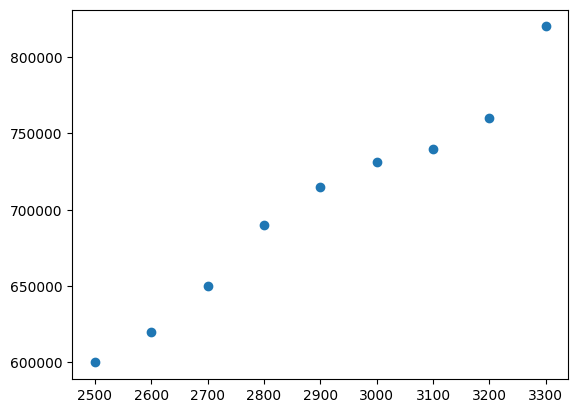

In [7]:
import matplotlib.pyplot as plt
plt.scatter(x,y)
plt.show()

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   area    9 non-null      int64
 1   price   9 non-null      int64
dtypes: int64(2)
memory usage: 276.0 bytes


In [9]:
data.describe()

,area,price
count,9.000000,9.000000
mean,2900.000000,702888.888889
std,273.861279,70454.674161
min,2500.000000,600000.000000
25%,2700.000000,650000.000000
50%,2900.000000,715000.000000
75%,3100.000000,740000.000000
max,3300.000000,820000.000000


In [11]:
data.corr() *100

,area,price
area,100.000000,98.536875
price,98.536875,100.000000


In [12]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test= train_test_split(x,y, test_size=0.2, random_state = 42)
x_train.shape

(7, 1)

In [13]:
y_train.shape

(7,)

In [14]:
x_test.shape

(2, 1)

In [15]:
y_test.shape

(2,)

In [16]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [28]:
from sklearn.metrics import r2_score
model.predict([[2500]])

C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([601714.28571429])

In [29]:
y_pred=model.predict(x_test)

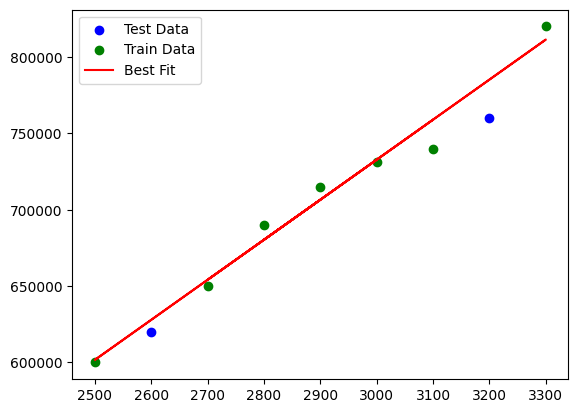

In [30]:
plt.scatter(x_test, y_test, color="blue", label="Test Data")
plt.scatter(x_train, y_train, color="green", label="Train Data")
plt.plot(x_train, model.predict(x_train), color="red", label="Best Fit")
plt.legend()
plt.show()

In [31]:
evaluation = pd.DataFrame({"Actual Value" : y_test,
"Predicted Value" : y_pred,
"Bias/ Error" : y_test - y_pred})
evaluation

,Actual Value,Predicted Value,Bias/ Error
7,760000,785214.285714,-25214.285714
1,620000,627928.571429,-7928.571429


In [32]:
import joblib

In [33]:
joblib.dump(model,"price_predictor.joblib")

['price_predictor.joblib']